<a href="https://colab.research.google.com/github/kaoru1018/diabetes-100k-analysis/blob/main/%E3%83%87%E3%83%BC%E3%82%BF%E3%82%B5%E3%82%A4%E3%82%A8%E3%83%B3%E3%82%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 設定 ---
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# 1. データの読み込み（エラー回避用）
file_name = 'diabetic_data.csv'

if os.path.exists(file_name):
#まず最初に、パソコンの中をのぞいて指定したファイルがあるかどうかをチェックします。
#osはWindowsとかMacの事

    df = pd.read_csv(file_name)
#動作: CSVファイルを読み込み、df という名前のデータフレーム（表形式のデータ）に保存します。
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者 × {df.shape[1]} 項目")
else:
    print(f"❌ エラー: '{file_name}' が見つかりません。")
    print("Kaggleからダウンロードしたファイルを、このプログラムと同じフォルダに置いてくださいね。")
    # ここで停止させないためのダミー
    df = pd.DataFrame()

# --- 2. 下準備（クレンジング） ---
if not df.empty:
    # 表（df）が空っぽでなければ、以下の処理を進める
    df_clean = df.copy()
    # 原本を汚さないようにコピーを作る

    # 数値データ：中央値で埋める
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    # データの中から「数字（整数や小数）」の列だけをリストアップする
    #つまり、「計算ができる『数値型』として認識されている列を、すべて自動でリストアップする」ということ
    for col in num_cols:
    # リストアップした列を一つずつ処理する
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    # その列の空っぽ（NaN）の場所に、その列の「中央値（median）」を入れて埋める

    # カテゴリ（文字）データ：最頻値（一番多い値）で埋める
    cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
    #もしその列の中に、一つでも空っぽ（isnull）のデータが含まれていたら（sumが0より大きければ）
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    #その列で「一番よく登場する言葉（最頻値：mode）」の1番目[0]を使って、空っぽの場所を埋めます。
    #Pandasのルールでは、同率1位が複数ある場合、「辞書順（あいうえお順やアルファベット順）」や「データの中に先に登場した順」で名簿の並びが決まります。

    # 3. 特殊な文字 "?" を数値に変換する
    # このデータセットは欠損値が "?" で入っていることが多いので、数値変換を試みます
    numeric_cols_to_convert = [
        'time_in_hospital', 'num_procedures', 'num_lab_procedures',
        'num_medications', 'number_outpatient', 'number_emergency',
        'number_inpatient'
    ]
    for col in numeric_cols_to_convert:
        if col in df_clean.columns:
            # errors='coerce' は「数字にできない文字は強制的に欠損値(NaN)にする」という意味
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            # 変換後に発生した欠損値を再度埋める
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # 4. 「30日以内の再入院」を予測ターゲットにする（二値化）
    # 元の readmitted は '<30', '>30', 'NO' の3種類。これを 1 or 0 に変える
    df_clean['readmitted_30d'] = (df_clean['readmitted'] == '<30').astype(int)

    # 5. 結果の表示
    print("✓ データ準備完了。統計分析を開始します。\n")
    print("--- 数値データの基本統計量（四分位を含む） ---")

    # describe() で平均、標準偏差、最小、四分位、最大を一気に計算
    stats = df_clean.describe()
    display(stats)

    # 6. 補足：特に重要な項目の「四分位」をピックアップして解説
    print("\n【分析ポイント】")
    hospital_stay = stats['time_in_hospital']
    print(f"・入院日数の中央値（50%）は {hospital_stay['50%']:.0f} 日です。")
    print(f"・入院日数の上位25%（75%タイル）は {hospital_stay['75%']:.0f} 日以上の人たちです。")

else:
    print(f"❌ エラー: '{file_name}' が見つかりません。")

✓ 読み込み成功: 94,564 患者 × 50 項目
✓ データ準備完了。統計分析を開始します。

--- 数値データの基本統計量（四分位を含む） ---


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_30d
count,9.456400e+04,9.456400e+04,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000
mean,1.475339e+08,5.152131e+07,2.050865,3.773074,5.776723,4.413794,43.163519,1.338776,15.951282,0.359386,0.191711,0.632757,7.361195,0.111850
std,8.289753e+07,3.669269e+07,1.464545,5.360602,4.131408,2.996457,19.525523,1.697379,8.131104,1.241147,0.925143,1.256454,1.943991,0.315184
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,8.076686e+07,2.321308e+07,1.000000,1.000000,1.000000,2.000000,32.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000
50%,1.454069e+08,4.375550e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000
75%,2.044408e+08,8.585396e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000
max,3.496593e+08,1.894451e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000



【分析ポイント】
・入院日数の中央値（50%）は 4 日です。
・入院日数の上位25%（75%タイル）は 6 日以上の人たちです。


✓ 読み込み成功: 101,766 患者 × 50 項目

--- 箱ひげ図を表示します ---


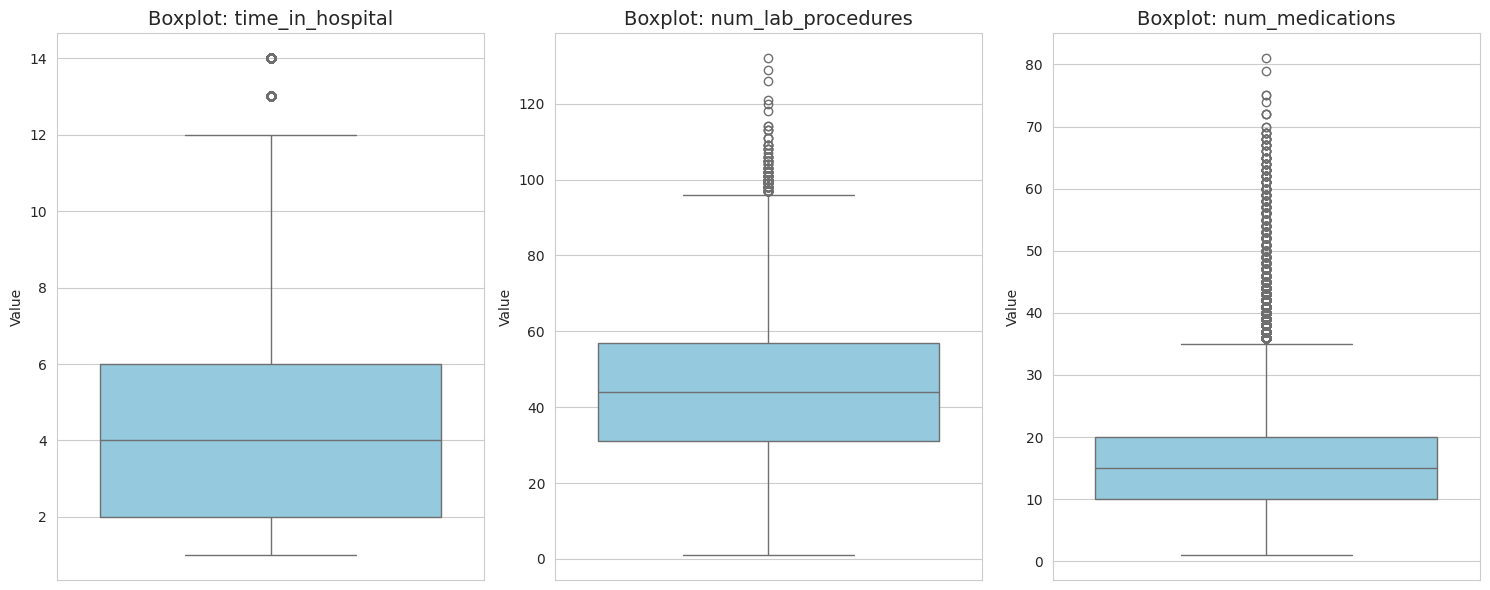

In [ ]:
#「入院日数」「検査数」「薬の数」の3つの重要な項目を比較する箱ひげ図

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 設定 ---
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# 1. データの読み込み（エラー回避用）
file_name = 'diabetic_data.csv'

if os.path.exists(file_name):
#まず最初に、パソコンの中をのぞいて指定したファイルがあるかどうかをチェックします。
#osはWindowsとかMacの事

    df = pd.read_csv(file_name)
#動作: CSVファイルを読み込み、df という名前のデータフレーム（表形式のデータ）に保存します。
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者 × {df.shape[1]} 項目")
else:
    print(f"❌ エラー: '{file_name}' が見つかりません。")
    print("Kaggleからダウンロードしたファイルを、このプログラムと同じフォルダに置いてくださいね。")
    # ここで停止させないためのダミー
    df = pd.DataFrame()

# --- 2. 下準備（クレンジング） ---
if not df.empty:
    # 表（df）が空っぽでなければ、以下の処理を進める
    df_clean = df.copy()
    # 原本を汚さないようにコピーを作る

    # 数値データ：中央値で埋める
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    # データの中から「数字（整数や小数）」の列だけをリストアップする
    #つまり、「計算ができる『数値型』として認識されている列を、すべて自動でリストアップする」ということ
    for col in num_cols:
    # リストアップした列を一つずつ処理する
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    # その列の空っぽ（NaN）の場所に、その列の「中央値（median）」を入れて埋める

    # カテゴリ（文字）データ：最頻値（一番多い値）で埋める
    cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
    #もしその列の中に、一つでも空っぽ（isnull）のデータが含まれていたら（sumが0より大きければ）
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    #その列で「一番よく登場する言葉（最頻値：mode）」の1番目[0]を使って、空っぽの場所を埋めます。
    #Pandasのルールでは、同率1位が複数ある場合、「辞書順（あいうえお順やアルファベット順）」や「データの中に先に登場した順」で名簿の並びが決まります。

    # 3. 特殊な文字 "?" を数値に変換する
    # このデータセットは欠損値が "?" で入っていることが多いので、数値変換を試みます
    numeric_cols_to_convert = [
        'time_in_hospital', 'num_procedures', 'num_lab_procedures',
        'num_medications', 'number_outpatient', 'number_emergency',
        'number_inpatient'
    ]
    for col in numeric_cols_to_convert:
        if col in df_clean.columns:
            # errors='coerce' は「数字にできない文字は強制的に欠損値(NaN)にする」という意味
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            # 変換後に発生した欠損値を再度埋める
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # 4. 「30日以内の再入院」を予測ターゲットにする（二値化）
    # 元の readmitted は '<30', '>30', 'NO' の3種類。これを 1 or 0 に変える
    df_clean['readmitted_30d'] = (df_clean['readmitted'] == '<30').astype(int)


#  5. 箱ひげ図（Boxplot）の作成
print("\n--- 箱ひげ図を表示します ---")

# グラフの土台（サイズ）を決める
plt.figure(figsize=(15, 6))

# 調べたい3つの項目をリストにする
plot_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications']

# 3つのグラフを横に並べて表示するためのループ
for i, col in enumerate(plot_cols, 1):
    plt.subplot(1, 3, i) # 1行3列のi番目にグラフを作る
    sns.boxplot(y=df_clean[col], color='skyblue') # 箱ひげ図を描く
    plt.title(f'Boxplot: {col}', fontsize=14) # グラフのタイトル
    plt.ylabel('Value') # 縦軸のラベル

# グラフ同士が重ならないように調整
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os

# --- 設定 ---
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# 1. データの読み込み（エラー回避用）
file_name = 'diabetic_data.csv'

if os.path.exists(file_name):
#まず最初に、パソコンの中をのぞいて指定したファイルがあるかどうかをチェックします。
#osはWindowsとかMacの事

    df = pd.read_csv(file_name)
#動作: CSVファイルを読み込み、df という名前のデータフレーム（表形式のデータ）に保存します。
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者 × {df.shape[1]} 項目")
else:
    print(f"❌ エラー: '{file_name}' が見つかりません。")
    print("Kaggleからダウンロードしたファイルを、このプログラムと同じフォルダに置いてくださいね。")
    # ここで停止させないためのダミー
    df = pd.DataFrame()

# --- 2. 下準備（クレンジング） ---
if not df.empty:
    # 表（df）が空っぽでなければ、以下の処理を進める
    df_clean = df.copy()
    # 原本を汚さないようにコピーを作る

    # 数値データ：中央値で埋める
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    # データの中から「数字（整数や小数）」の列だけをリストアップする
    #つまり、「計算ができる『数値型』として認識されている列を、すべて自動でリストアップする」ということ
    for col in num_cols:
    # リストアップした列を一つずつ処理する
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    # その列の空っぽ（NaN）の場所に、その列の「中央値（median）」を入れて埋める

    # カテゴリ（文字）データ：最頻値（一番多い値）で埋める
    cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
    #もしその列の中に、一つでも空っぽ（isnull）のデータが含まれていたら（sumが0より大きければ）
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    #その列で「一番よく登場する言葉（最頻値：mode）」の1番目[0]を使って、空っぽの場所を埋めます。
    #Pandasのルールでは、同率1位が複数ある場合、「辞書順（あいうえお順やアルファベット順）」や「データの中に先に登場した順」で名簿の並びが決まります。

    # 3. 特殊な文字 "?" を数値に変換する
    # このデータセットは欠損値が "?" で入っていることが多いので、数値変換を試みます
    numeric_cols_to_convert = [
        'time_in_hospital', 'num_procedures', 'num_lab_procedures',
        'num_medications', 'number_outpatient', 'number_emergency',
        'number_inpatient'
    ]
    for col in numeric_cols_to_convert:
        if col in df_clean.columns:
            # errors='coerce' は「数字にできない文字は強制的に欠損値(NaN)にする」という意味
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            # 変換後に発生した欠損値を再度埋める
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # 4. 「30日以内の再入院」を予測ターゲットにする（二値化）
    # 元の readmitted は '<30', '>30', 'NO' の3種類。これを 1 or 0 に変える
    df_clean['readmitted_30d'] = (df_clean['readmitted'] == '<30').astype(int)

    # データ全体の中にある "?" の出現回数をカウントする
    missing_summary = (df == '?').sum()

    # 欠損が存在する（0より大きい）項目だけを表示
    print("--- 項目別の欠損値（?）の数 ---")
    print(missing_summary[missing_summary > 0])

    # 全体に対する欠損率（%）も見てみる
    missing_ratio = (missing_summary / len(df)) * 100
    print("\n--- 欠損率（%） ---")
    print(missing_ratio[missing_ratio > 0])

✓ 読み込み成功: 101,766 患者 × 50 項目
--- 項目別の欠損値（?）の数 ---
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64

--- 欠損率（%） ---
race                  2.233555
weight               96.858479
payer_code           39.557416
medical_specialty    49.082208
diag_1                0.020636
diag_2                0.351787
diag_3                1.398306
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import os

# 1. データの読み込み
file_name = 'diabetic_data.csv'
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者 × {df.shape[1]} 項目")
else:
    print("❌ ファイルが見つかりません。")
    df = pd.DataFrame()

if not df.empty:
    # --- 【工程1：現状把握】 まずは原本で欠損（?）を数える ---
    missing_summary = (df == '?').sum()
    missing_ratio = (missing_summary / len(df)) * 100

    print("\n--- 欠損値の現状報告 ---")
    print(missing_ratio[missing_ratio > 0])

    # --- 【工程2：断捨離】 欠損が多すぎる列を「埋める前」に捨てる ---
    # 欠損率が 30% を超える列は、分析を歪めるので削除候補にします
    cols_to_drop = missing_ratio[missing_ratio > 30].index.tolist()
    df_clean = df.drop(columns=cols_to_drop).copy()
    print(f"\n✓ 欠損過多により削除した列: {cols_to_drop}")

    # --- 【工程3：型変換】 '?' を数値に変える（この時 NaN になる） ---
    numeric_cols = [
        'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'
    ]

    for col in numeric_cols:
        if col in df_clean.columns:
            # errors='coerce' で '?' を NaN（空っぽ）に変換
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # --- 【工程4：穴埋め】 最後に残った NaN を中央値で埋める ---
    # 数値列の中央値埋め
    num_cols_final = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols_final:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # カテゴリ列の最頻値埋め（残った NaN 用）
    cat_cols_final = df_clean.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols_final:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    # ターゲット（再入院）の作成
    df_clean['readmitted_30d'] = (df_clean['readmitted'] == '<30').astype(int)

    print("\n--- 最終的なデータの状態 ---")
    print(f"残った項目数: {df_clean.shape[1]}")
    print("✓ 全ての欠損値の処理が完了しました。")

✓ 読み込み成功: 101,766 患者 × 50 項目

--- 欠損値の現状報告 ---
race                  2.233555
weight               96.858479
payer_code           39.557416
medical_specialty    49.082208
diag_1                0.020636
diag_2                0.351787
diag_3                1.398306
dtype: float64

✓ 欠損過多により削除した列: ['weight', 'payer_code', 'medical_specialty']

--- 最終的なデータの状態 ---
残った項目数: 48
✓ 全ての欠損値の処理が完了しました。


✓ 読み込み成功: 101,766 患者 × 50 項目

--- デシル分析：入院日数と再入院率の関係 ---


/tmp/ipykernel_35272/2869600163.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_analysis = df_clean.groupby('decile')['readmitted_30d'].mean() * 100


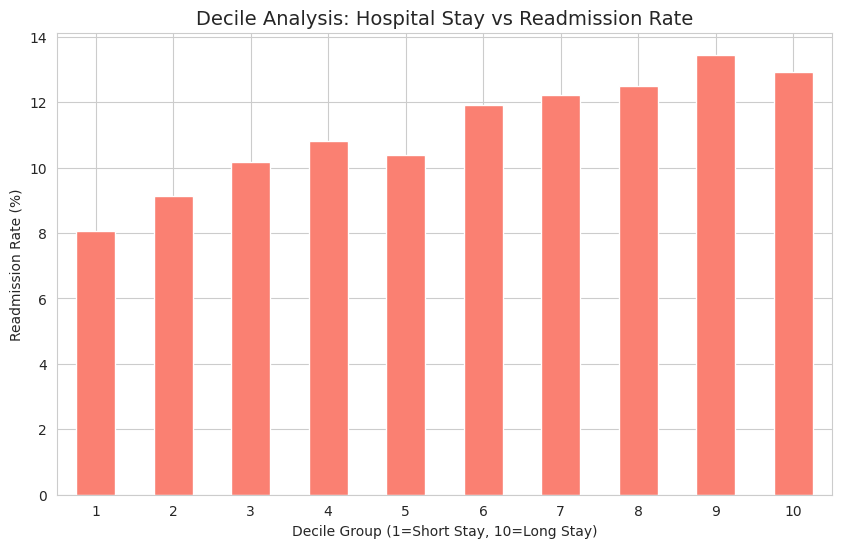

decile
1      8.057384
2      9.148079
3     10.180818
4     10.808686
5     10.377358
6     11.928859
7     12.224843
8     12.498772
9     13.453223
10    12.921293
Name: readmitted_30d, dtype: float64


In [ ]:
#デシル分析

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 設定 ---
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# 1. データの読み込み（エラー回避用）
file_name = 'diabetic_data.csv'

if os.path.exists(file_name):
#まず最初に、パソコンの中をのぞいて指定したファイルがあるかどうかをチェックします。
#osはWindowsとかMacの事

    df = pd.read_csv(file_name)
#動作: CSVファイルを読み込み、df という名前のデータフレーム（表形式のデータ）に保存します。
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者 × {df.shape[1]} 項目")
else:
    print(f"❌ エラー: '{file_name}' が見つかりません。")
    print("Kaggleからダウンロードしたファイルを、このプログラムと同じフォルダに置いてくださいね。")
    # ここで停止させないためのダミー
    df = pd.DataFrame()

# --- 2. 下準備（クレンジング） ---
if not df.empty:
    # 表（df）が空っぽでなければ、以下の処理を進める
    df_clean = df.copy()
    # 原本を汚さないようにコピーを作る

    # 数値データ：中央値で埋める
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    # データの中から「数字（整数や小数）」の列だけをリストアップする
    #つまり、「計算ができる『数値型』として認識されている列を、すべて自動でリストアップする」ということ
    for col in num_cols:
    # リストアップした列を一つずつ処理する
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    # その列の空っぽ（NaN）の場所に、その列の「中央値（median）」を入れて埋める

    # カテゴリ（文字）データ：最頻値（一番多い値）で埋める
    cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
    #もしその列の中に、一つでも空っぽ（isnull）のデータが含まれていたら（sumが0より大きければ）
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    #その列で「一番よく登場する言葉（最頻値：mode）」の1番目[0]を使って、空っぽの場所を埋めます。
    #Pandasのルールでは、同率1位が複数ある場合、「辞書順（あいうえお順やアルファベット順）」や「データの中に先に登場した順」で名簿の並びが決まります。

    # 3. 特殊な文字 "?" を数値に変換する
    # このデータセットは欠損値が "?" で入っていることが多いので、数値変換を試みます
    numeric_cols_to_convert = [
        'time_in_hospital', 'num_procedures', 'num_lab_procedures',
        'num_medications', 'number_outpatient', 'number_emergency',
        'number_inpatient'
    ]
    for col in numeric_cols_to_convert:
        if col in df_clean.columns:
            # errors='coerce' は「数字にできない文字は強制的に欠損値(NaN)にする」という意味
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            # 変換後に発生した欠損値を再度埋める
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # 4. 「30日以内の再入院」を予測ターゲットにする（二値化）
    # 元の readmitted は '<30', '>30', 'NO' の3種類。これを 1 or 0 に変える
    df_clean['readmitted_30d'] = (df_clean['readmitted'] == '<30').astype(int)

    # 5. デシル分析（入院日数で10等分）
print("\n--- デシル分析：入院日数と再入院率の関係 ---")

# 1. 入院日数に基づいて、患者を10個のグループ（1〜10）に分ける
# qcutは「人数が均等になるように」切り分ける命令です
df_clean['decile'] = pd.qcut(df_clean['time_in_hospital'].rank(method='first'), 10, labels=range(1, 11))

# 2. グループごとに「30日以内再入院率」の平均を計算する
decile_analysis = df_clean.groupby('decile')['readmitted_30d'].mean() * 100

# 3. 結果をグラフ（棒グラフ）で表示
plt.figure(figsize=(10, 6))
decile_analysis.plot(kind='bar', color='salmon')
plt.title('Decile Analysis: Hospital Stay vs Readmission Rate', fontsize=14)
plt.xlabel('Decile Group (1=Short Stay, 10=Long Stay)')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.show()

# 数値でも表示
print(decile_analysis)

✓ 読み込み成功: 60,788 患者 × 50 項目

--- PCA 寄与率の結果 ---
第1主成分: 26.91%
第2主成分: 19.04%
第3主成分: 14.19%
第4主成分: 12.86%
第5主成分: 10.64%
第6主成分: 9.63%
第7主成分: 6.73%

累積寄与率（上位2つ合計）: 45.96%


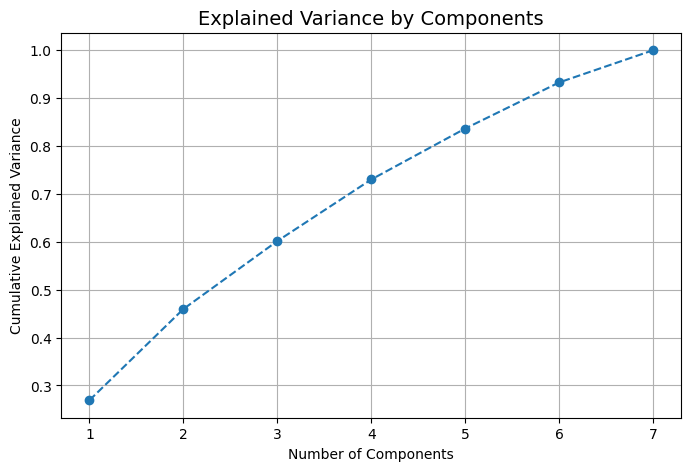

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. データの読み込み
file_name = 'diabetic_data.csv'
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者 × {df.shape[1]} 項目")
else:
    print("❌ ファイルが見つかりません。")
    df = pd.DataFrame()

if not df.empty:
    # --- 【工程1：現状把握】 まずは原本で欠損（?）を数える ---
    missing_summary = (df == '?').sum()
    missing_ratio = (missing_summary / len(df)) * 100

    # --- 【工程2：断捨離】 欠損が多すぎる列を「埋める前」に捨てる ---
    # 欠損率が 30% を超える列は、分析を歪めるので削除候補にします
    cols_to_drop = missing_ratio[missing_ratio > 30].index.tolist()
    df_clean = df.drop(columns=cols_to_drop).copy()


    # --- 【工程3：型変換】 '?' を数値に変える（この時 NaN になる） ---
    numeric_cols = [
        'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'
    ]

    for col in numeric_cols:
        if col in df_clean.columns:
            # errors='coerce' で '?' を NaN（空っぽ）に変換
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # --- 【工程4：穴埋め】 最後に残った NaN を中央値で埋める ---
    # 数値列の中央値埋め
    num_cols_final = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols_final:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # カテゴリ列の最頻値埋め（残った NaN 用）
    cat_cols_final = df_clean.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols_final:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# ---【工程5: PCA（主成分分析）の実行】 ---

# 1. 分析に使用する数値項目を選択
# 欠損値がほとんどなく、かつ患者の状態を表す「7つの指標」を使います
pca_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'
]

# 2. データの準備
x = df_clean[pca_features]

# 3. 標準化（必須ステップ：平均0、分散1に変換）
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 4. PCAの実行（計算して変換する）
pca = PCA()
principal_components = pca.fit_transform(x_scaled)

# 5. 各主成分がどれくらい情報を説明しているか（寄与率）を表示
print("\n--- PCA 寄与率の結果 ---")
ev_ratio = pca.explained_variance_ratio_
for i, ratio in enumerate(ev_ratio):
    print(f"第{i+1}主成分: {ratio*100:.2f}%")

# 6. 累積寄与率（上位から足していくと何％になるか）
cum_ratio = np.cumsum(ev_ratio)
print(f"\n累積寄与率（上位2つ合計）: {cum_ratio[1]*100:.2f}%")

# 7. グラフ（スクリープロット）で確認
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_ratio) + 1), cum_ratio, marker='o', linestyle='--')
plt.title('Explained Variance by Components', fontsize=14)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

✓ 読み込み成功: 101,766 患者データ

--- 第1主成分（PC1）の構成要素（寄与率: 26.94%） ---
num_medications       0.597399
time_in_hospital      0.554744
num_lab_procedures    0.409974
num_procedures        0.399552
number_inpatient      0.083919
number_outpatient     0.021596
number_emergency      0.012033
Name: PC1, dtype: float64


/tmp/ipykernel_4694/3938476165.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


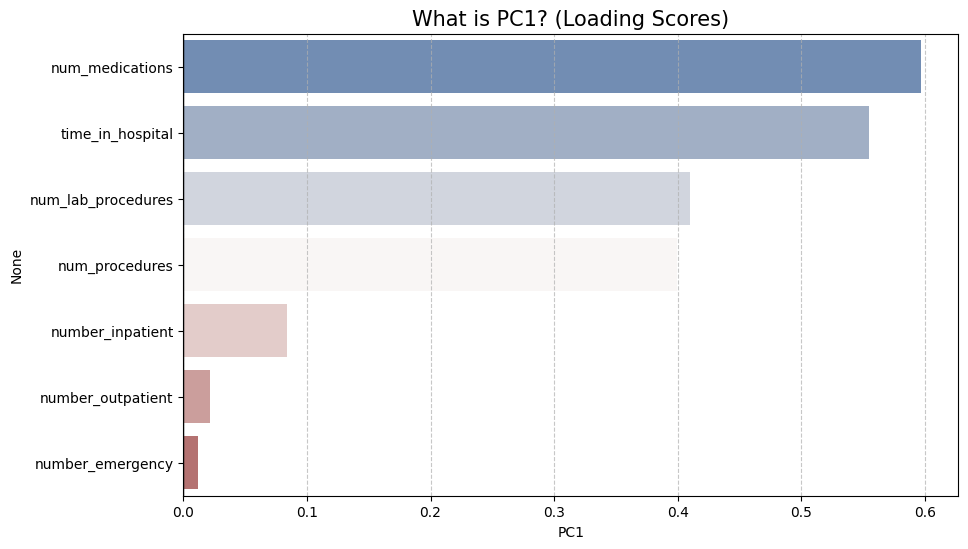

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. データの読み込み
file_name = 'diabetic_data.csv'
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者データ")

    # --- 工程2：断捨離（欠損値処理） ---
    # missing_summary を定義してから計算します
    missing_summary = (df == '?').sum()
    missing_ratio = (missing_summary / len(df)) * 100

    cols_to_drop = missing_ratio[missing_ratio > 30].index.tolist()
    df_clean = df.drop(columns=cols_to_drop).copy()

    # --- 工程3：型変換と穴埋め ---
    pca_features = [
        'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'
    ]

    for col in pca_features:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # --- 工程5: PCA（主成分分析）の実行 ---
    x = df_clean[pca_features]

    # scaler をしっかり定義します
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)

    pca = PCA()
    pca.fit(x_scaled)

    # --- 結果の表示 ---
    print("\n--- 第1主成分（PC1）の構成要素（寄与率: {:.2f}%） ---".format(pca.explained_variance_ratio_[0]*100))
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(len(pca_features))],
        index=pca_features
    )
    print(loadings['PC1'].sort_values(ascending=False))

    # PC1の中身をグラフ化
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=loadings['PC1'].sort_values(ascending=False),
        y=loadings['PC1'].sort_values(ascending=False).index,
        palette='vlag'
    )
    plt.title('What is PC1? (Loading Scores)', fontsize=15)
    plt.axvline(0, color='black', lw=1)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

else:
    print("❌ ファイルが見つかりません。")


✓ 読み込み成功: 101,766 患者データ

--- 第2主成分（PC2）の構成要素（寄与率: 19.21%） ---
number_inpatient      0.646920
number_emergency      0.623878
number_outpatient     0.380448
num_lab_procedures    0.031373
time_in_hospital      0.012116
num_medications      -0.005964
num_procedures       -0.215322
Name: PC2, dtype: float64


/tmp/ipykernel_4694/2549256560.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


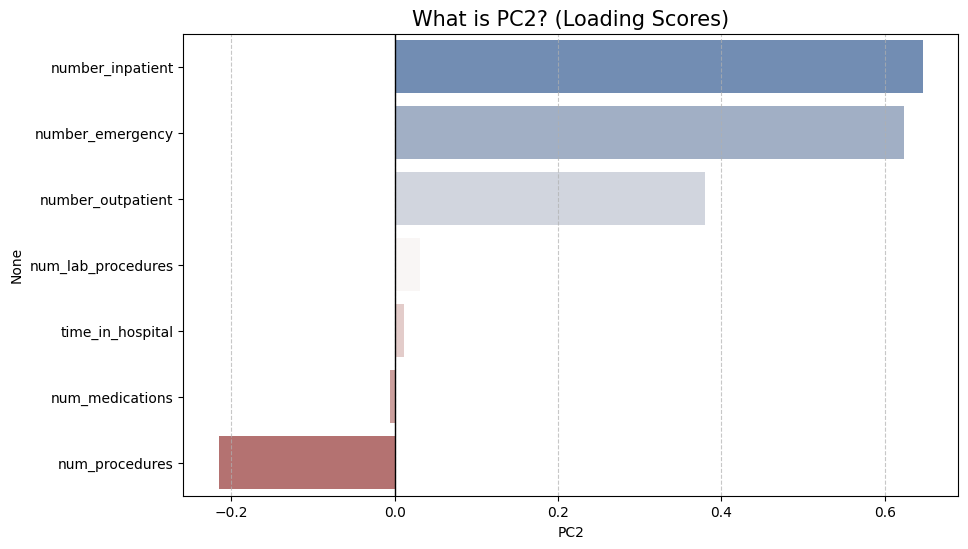

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. データの読み込み
file_name = 'diabetic_data.csv'
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者データ")

    # --- 工程2：断捨離（欠損値処理） ---
    # missing_summary を定義してから計算します
    missing_summary = (df == '?').sum()
    missing_ratio = (missing_summary / len(df)) * 100

    cols_to_drop = missing_ratio[missing_ratio > 30].index.tolist()
    df_clean = df.drop(columns=cols_to_drop).copy()

    # --- 工程3：型変換と穴埋め ---
    pca_features = [
        'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'
    ]

    for col in pca_features:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # --- 工程5: PCA（主成分分析）の実行 ---
    x = df_clean[pca_features]

    # scaler をしっかり定義します
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)

    pca = PCA()
    pca.fit(x_scaled)

    # --- 結果の表示 ---
    print("\n--- 第2主成分（PC2）の構成要素（寄与率: {:.2f}%） ---".format(pca.explained_variance_ratio_[1]*100))
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(len(pca_features))],
        index=pca_features
    )
    print(loadings['PC2'].sort_values(ascending=False))

    # PC2の中身をグラフ化
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=loadings['PC2'].sort_values(ascending=False),
        y=loadings['PC2'].sort_values(ascending=False).index,
        palette='vlag'
    )
    plt.title('What is PC2? (Loading Scores)', fontsize=15)
    plt.axvline(0, color='black', lw=1)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

else:
    print("❌ ファイルが見つかりません。")


✓ 読み込み成功: 60,788 患者データ

--- PCA 寄与率の結果 ---
第1主成分 (PC1): 26.91% (治療ボリュームの軸)
第2主成分 (PC2): 19.04% (受診歴・リピーターの軸)
累積寄与率 (上位2つ合計): 45.96%


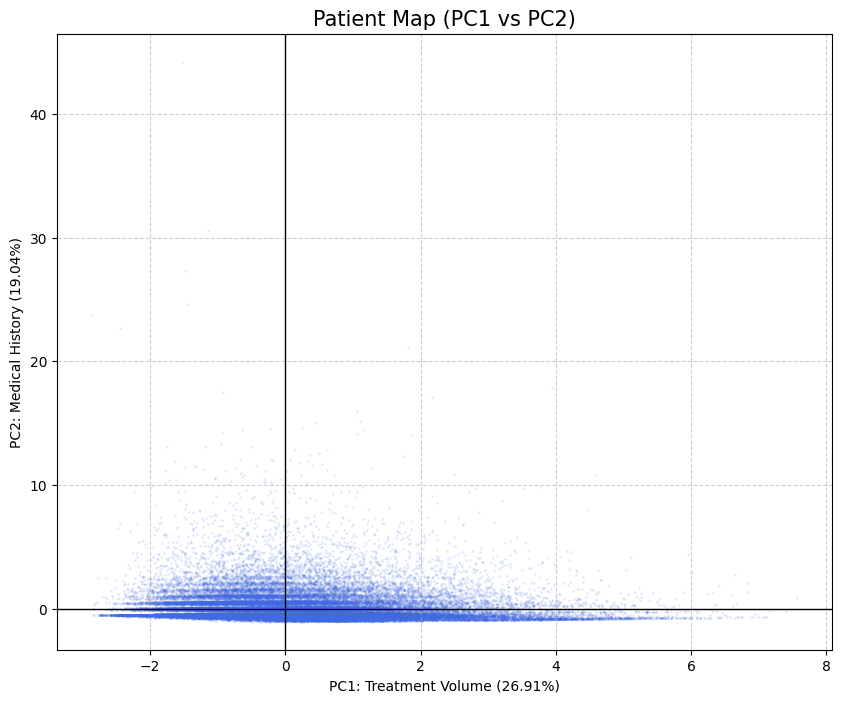

In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. データの読み込み
file_name = 'diabetic_data.csv'
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者データ")

    # --- 工程2：断捨離（欠損値処理） ---
    # 欠損率を計算し、30%を超える列を削除
    missing_summary = (df == '?').sum()
    missing_ratio = (missing_summary / len(df)) * 100
    cols_to_drop = missing_ratio[missing_ratio > 30].index.tolist()
    df_clean = df.drop(columns=cols_to_drop).copy()

    # --- 工程3：型変換と穴埋め ---
    # PCAで使用する「7つの指標」
    pca_features = [
        'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'
    ]

    # 数値への変換と、欠損値を中央値で穴埋め
    for col in pca_features:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # --- 工程4: PCA（主成分分析）の実行 ---
    x = df_clean[pca_features]

    # 単位を揃える（標準化）
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)

    # PCAの計算
    pca = PCA()
    principal_components = pca.fit_transform(x_scaled)

    # --- 工程5: 結果の表示 ---
    print("\n--- PCA 寄与率の結果 ---")
    ev_ratio = pca.explained_variance_ratio_
    print(f"第1主成分 (PC1): {ev_ratio[0]*100:.2f}% (治療ボリュームの軸)")
    print(f"第2主成分 (PC2): {ev_ratio[1]*100:.2f}% (受診歴・リピーターの軸)")
    print(f"累積寄与率 (上位2つ合計): {sum(ev_ratio[:2])*100:.2f}%")

    # --- 工程6: 第1・第2主成分による「患者マップ」の描画 ---
    # PCAの結果をデータフレーム化
    pca_df = pd.DataFrame(
        data=principal_components,
        columns=[f'PC{i+1}' for i in range(len(pca_features))]
    )

    plt.figure(figsize=(10, 8))

    # 散布図を描画（点の透明度を alpha=0.1 にして、重なり具合を分かりやすくします）
    plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.1, s=1, c='royalblue')

    plt.title('Patient Map (PC1 vs PC2)', fontsize=15)
    plt.xlabel(f'PC1: Treatment Volume ({ev_ratio[0]*100:.2f}%)')
    plt.ylabel(f'PC2: Medical History ({ev_ratio[1]*100:.2f}%)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # 平均値（0のライン）を強調する黒い十字線を引く
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)

    plt.show()

else:
    print("❌ ファイルが見つかりません。")


✓ 読み込み成功: 101,766 患者データ

--- PCA 寄与率の結果 ---
第1主成分 (PC1): 26.94% (治療ボリュームの軸)
第2主成分 (PC2): 19.21% (受診歴・リピーターの軸)
累積寄与率 (上位2つ合計): 46.15%


<Figure size 1000x800 with 0 Axes>

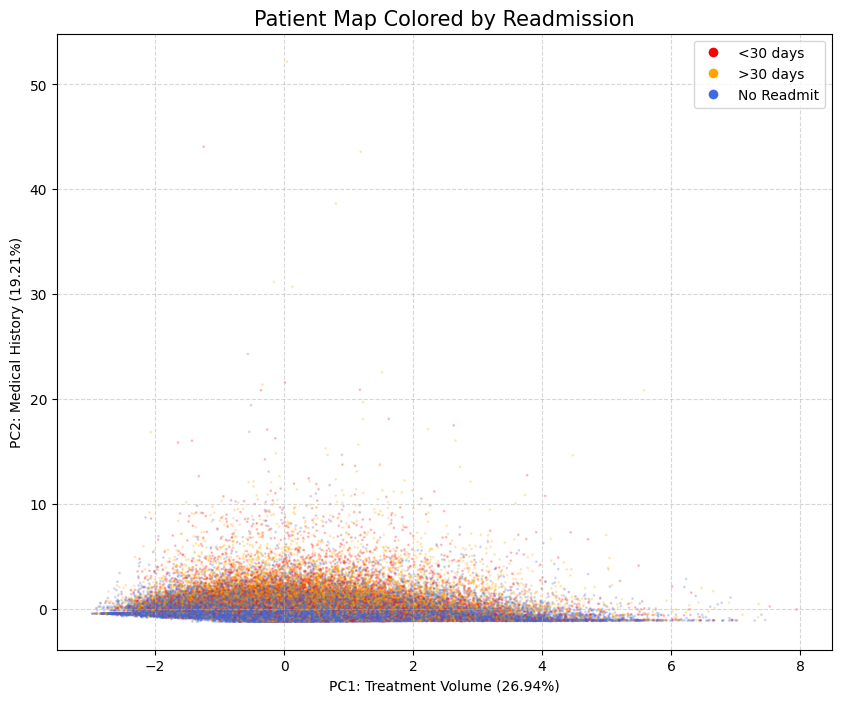

In [18]:
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. データの読み込み
file_name = 'diabetic_data.csv'
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者データ")

    # --- 工程2：断捨離（欠損値処理） ---
    # 欠損率を計算し、30%を超える列を削除
    missing_summary = (df == '?').sum()
    missing_ratio = (missing_summary / len(df)) * 100
    cols_to_drop = missing_ratio[missing_ratio > 30].index.tolist()
    df_clean = df.drop(columns=cols_to_drop).copy()

    # --- 工程3：型変換と穴埋め ---
    # PCAで使用する「7つの指標」
    pca_features = [
        'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'
    ]

    # 数値への変換と、欠損値を中央値で穴埋め
    for col in pca_features:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())


    # --- 工程4: PCA（主成分分析）の実行 ---
    x = df_clean[pca_features]

    # 単位を揃える（標準化）
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)



    # PCAの計算
    pca = PCA()
    principal_components = pca.fit_transform(x_scaled)



    # --- 工程5: 結果の表示 ---
    print("\n--- PCA 寄与率の結果 ---")
    ev_ratio = pca.explained_variance_ratio_
    print(f"第1主成分 (PC1): {ev_ratio[0]*100:.2f}% (治療ボリュームの軸)")
    print(f"第2主成分 (PC2): {ev_ratio[1]*100:.2f}% (受診歴・リピーターの軸)")
    print(f"累積寄与率 (上位2つ合計): {sum(ev_ratio[:2])*100:.2f}%")

    # --- 工程6: 第1・第2主成分による「患者マップ」の描画 ---
    # PCAの結果をデータフレーム化
    pca_df = pd.DataFrame(
        data=principal_components,
        columns=[f'PC{i+1}' for i in range(len(pca_features))]
    )

    plt.figure(figsize=(10, 8))



   # --- 7. 再入院（readmitted）で色分けした「患者マップ」を描く ---

# 色のマップを定義（<30:赤, >30:オレンジ, NO:青）
color_map = {'<30': 'red', '>30': 'orange', 'NO': 'royalblue'}
# df_cleanの'readmitted'列を使って、各患者の色を決める
patient_colors = df_clean['readmitted'].map(color_map)

# PCAの結果をデータフレームにする（前のコードと同じ）
pca_df = pd.DataFrame(
    data=principal_components,
    columns=[f'PC{i+1}' for i in range(len(pca_features))]
)

plt.figure(figsize=(10, 8))

# 散布図を描画（c= に patient_colors を指定）
# 重なりを見やすくするため、alpha（透明度）と s（点のサイズ）を調整
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=patient_colors, # ここで色を指定
    alpha=0.2,        # 少し濃くした
    s=1               # 点は小さく
)

plt.title('Patient Map Colored by Readmission', fontsize=15)
plt.xlabel(f'PC1: Treatment Volume ({ev_ratio[0]*100:.2f}%)')
plt.ylabel(f'PC2: Medical History ({ev_ratio[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.5)

# 凡例（Legend）を手動で追加
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='<30 days', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='>30 days', markerfacecolor='orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='No Readmit', markerfacecolor='royalblue', markersize=8)
]
plt.legend(handles=legend_elements, loc='upper right')

plt.show()

✓ 読み込み成功: 101,766 患者データ

--- LightGBM による再入院予測モデルの作成 ---
学習データ件数: 81,412件
テストデータ件数: 20,354件
テストデータ内の再入院('<30')件数: 2,271件

学習中...
学習完了。

--- モデル評価結果 ---
全般的な正解率 (Accuracy): 88.86%

詳細なレポート (Classification Report):
              precision    recall  f1-score   support

     No/Late       0.89      1.00      0.94     18083
    <30 days       0.56      0.01      0.02      2271

    accuracy                           0.89     20354
   macro avg       0.72      0.50      0.48     20354
weighted avg       0.85      0.89      0.84     20354



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20877 (\N{CJK UNIFIED IDEOGRAPH-518D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

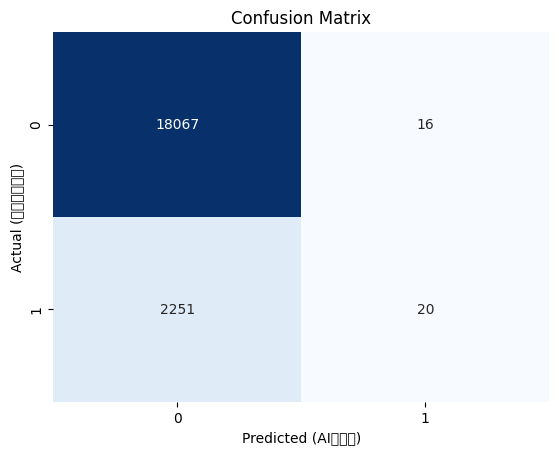

In [19]:
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. データの読み込み
file_name = 'diabetic_data.csv'
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者データ")

    # --- 工程2：断捨離（欠損値処理） ---
    # 欠損率を計算し、30%を超える列を削除
    missing_summary = (df == '?').sum()
    missing_ratio = (missing_summary / len(df)) * 100
    cols_to_drop = missing_ratio[missing_ratio > 30].index.tolist()
    df_clean = df.drop(columns=cols_to_drop).copy()

    # --- 工程3：型変換と穴埋め ---
    # PCAで使用する「7つの指標」
    pca_features = [
        'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'
    ]

    # 数値への変換と、欠損値を中央値で穴埋め
    for col in pca_features:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# --- 工程4: PCA（主成分分析）の実行 ---
    x = df_clean[pca_features]
# 単位を揃える（標準化）
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)

    # PCAの計算
    pca = PCA()
    principal_components = pca.fit_transform(x_scaled)

# --- 【ここから LightGBM モデル作成】 ---
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n--- LightGBM による再入院予測モデルの作成 ---")

# 1. 目的変数（答え）の準備：30日以内の再入院('<30')を1、それ以外を0にする
y = df_clean['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# 2. 特徴量（予測のヒント）の準備：PCAに使った7項目
# （LightGBMは欠損値を扱えますが、今回は前処理済みのものを使います）
X = df_clean[pca_features]

# 3. データを「学習用」と「テスト用」に分ける（8:2）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"学習データ件数: {len(X_train):,}件")
print(f"テストデータ件数: {len(X_test):,}件")
print(f"テストデータ内の再入院('<30')件数: {sum(y_test):,}件")

# 4. LightGBMモデルの設定
# 初回なのでシンプルな設定にします
model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',   # 2値分類（再入院するか/しないか）
    metric='binary_logloss',
    learning_rate=0.05,
    n_estimators=100,
    random_state=42,
    verbose=-1            # 警告出力を減らす
)

# 5. モデルの学習（練習問題を解かせる）
print("\n学習中...")
model.fit(X_train, y_train)
print("学習完了。")

# 6. テストデータで予測（本番テスト）
y_pred = model.predict(X_test)

# 7. 結果の評価
print("\n--- モデル評価結果 ---")
print(f"全般的な正解率 (Accuracy): {accuracy_score(y_test, y_pred)*100:.2f}%")

print("\n詳細なレポート (Classification Report):")
# 特に'1'（再入院あり）のRecall（再現率：実際の再入院をどれだけ当てられたか）に注目
print(classification_report(y_test, y_pred, target_names=['No/Late', '<30 days']))

# 混同行列（どのくらい正解して、どのくらい間違えたかの表）
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted (AIの予測)')
plt.ylabel('Actual (実際の再入院)')
plt.title('Confusion Matrix')
plt.show()